# comparing particle number distributions of the particle to full models
Tim Tyree<br>
6.6.2025

In [1]:
import sys,os
og_stdout=sys.stdout
from lib.my_initialization import *
os.chdir(nb_dir)
from lib import *
# import cupy, cudf
# from lib.rapids_func import *
import seaborn as sns
import matplotlib.ticker as mtick
import warnings
warnings.simplefilter("ignore", UserWarning)
%load_ext autoreload
%autoreload 2

In [57]:
import seaborn as sns
#reset matplotlib
plt.plot([1]*4)
plt.close()
#reset matplotlib settings
import matplotlib as mpl
sns.reset_orig()
mpl.rc_file_defaults()

# define module

# dev

In [29]:
printing=True
use_save_df_to_parquet_by=True
use_save_df_to_parquet_by=False
#load fortranic tip positions
nb_dir_ = '/Users/timothytyree/Documents/GitHub/care/notebooks'
folder=f"{nb_dir_}/Data/from_wjr/positions_fk/200x200"
fn = 'tippos_per_c_001'
folder=f"{nb_dir_}/Data/from_wjr/positions_lr/200x200"
fn = 'tippos_per_001'
input_dir = os.path.join(folder,fn)
log_folder_parquet=f'{folder}/positions'
assert os.path.exists(input_dir)
if use_save_df_to_parquet_by:
    df_log=parse_fortranic_tip_pos(input_dir)
    #partition df_log into a folder of tip logs
    save_df_to_parquet_by(df_log,log_folder_parquet,by='trial_num',compression='snappy',index=None)
    print(f"saved to spiral tip positions to {log_folder_parquet=}")
    #determine width and height of the computational domain input the discretization
    width,height=df_log.describe().loc['max'][['x','y']].values.T
    del df_log
else:
    width=200
    height=200

In [34]:
N0=2
t_lst=[]
nv_lst=[]
for fn in os.listdir(log_folder_parquet):
    try:
        trial_num = eval(fn.split('=')[1])
        # load tip position data
        g=load_parquet_by_trial_num(trial_num=trial_num,folder_parquet=log_folder_parquet)
        n_series = g.groupby(by='t')['n'].min()
        t0_values = n_series[n_series==N0].index.values
        tf = n_series.index.values.max()
        t_values = tf-t0_values
        #record
        t_lst.extend(t_values)
        nv = g.groupby('t')['n'].mean()[::1000] #once every 1s
        nv = nv[nv%2==0]
        nv_lst.extend(nv)
    except IndexError as e:
        pass
        #print(f"IndexError for {fn}: {e}")
n_series.max()

14

In [35]:
g.groupby('t')['n'].mean()

t
1.0       12.0
2.0       10.0
3.0       10.0
4.0        8.0
5.0        8.0
          ... 
1712.0     2.0
1713.0     2.0
1714.0     2.0
1715.0     2.0
1716.0     2.0
Name: n, Length: 1716, dtype: float64

In [36]:
len(nv_lst)

849

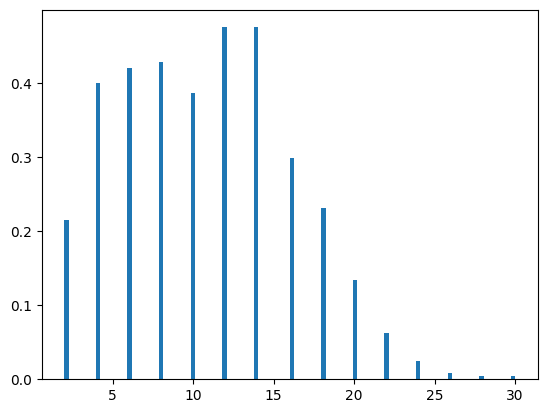

In [37]:
plt.hist(nv_lst,density=True,bins=100)
plt.show()

In [51]:
#print summary stats for distribution of particle numbers
nv_values = np.array(nv_lst)
meann,Delta_meann,num_obs,p_normal=comp_mean_bootstrap_uncertainty(nv_values)
print(f"{meann=},{Delta_meann=},{num_obs=},{p_normal=}")
median = np.median(nv_values)
q25 = np.quantile(nv_values,0.25)
q75 = np.quantile(nv_values,0.75)
print(f"median: {median} (IQR: {q25}-{q75}, N={nv_values.shape[0]})")

meann=10.725559481743227,Delta_meann=0.36351918937020883,num_obs=849,p_normal=0.816546884410534
median: 10.0 (IQR: 6.0-14.0, N=849)


In [52]:
#find corresponding data from the particle model
# nb_dir.split('/')
'/Users/timothytyree/Documents/GitHub/bgmc/python/data/'
nb_dir

'/Users/timothytyree/Documents/GitHub/care/notebooks'

In [53]:
# !conda env list
import sys
print(sys.executable)

/Users/timothytyree/opt/miniconda3/envs/pyenv/bin/python
